# KNN Variants for Class Imbalance — Final Report

**CC2008 Machine Learning I · University of Porto**  
Dataset Group 2: Binary Classification under Class Imbalance

---

## Narrative

Standard k-nearest-neighbours classifiers treat majority and minority classes symmetrically.
Under severe class imbalance this is a structural error: majority samples are always
statistically closer at every rank simply because more of them exist — not because of any
signal in the data.

This notebook tells the story of how we identified that structural bias, derived a
mathematically principled correction via order statistics, and validated that correction
across 49 benchmark datasets.

**Structure**
1. Setup & data suite  
2. The structural bias of KNNOptK  
3. Theoretical derivation of KNNFairRank  
4. Algorithm implementations  
5. Experimental setup  
6. Results  
7. Statistical validation (Friedman · Wilcoxon · Critical Difference)  
8. Discussion & Conclusions


## 1 · Setup & Dataset Suite

In [1]:
import warnings, sys, os
warnings.filterwarnings("ignore")

# Ensure project root is on sys.path (works in both nbconvert and interactive use)
for _candidate in [".", "..", os.path.join(os.path.dirname(os.getcwd()), "")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        os.chdir(_candidate)
        break

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from src.data.loader import load_all_datasets
from src.utils.config import load_config

cfg  = load_config()
SEED = cfg["random_seed"]
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 11,
})

PALETTE = {
    "KNNOptK":              "#6c757d",
    "KNNWeighted":          "#fd7e14",
    "SMOTE+KNN":            "#0dcaf0",
    "KNNFairRank":          "#0d6efd",
    "KNNFairRankCV":        "#6610f2",
    "KNNFairRankJointCV":   "#d63384",
    "KNNFairRankJackknife":          "#198754",
    "KNNFairRankEnsemble":          "#20c997",
    "KNNFairRankOptVotes":           "#ffc107",
    "KNNFairRankTopoJointBootstrap": "#dc3545",
}

ALGOS = list(PALETTE.keys())
print("Setup complete. Seed =", SEED)

Setup complete. Seed = 42


Loaded 49 datasets

Imbalance Ratio  — min: 0.01 | median: 0.11 | max: 0.24
Samples          — min: 100 | median: 600 | max: 9961


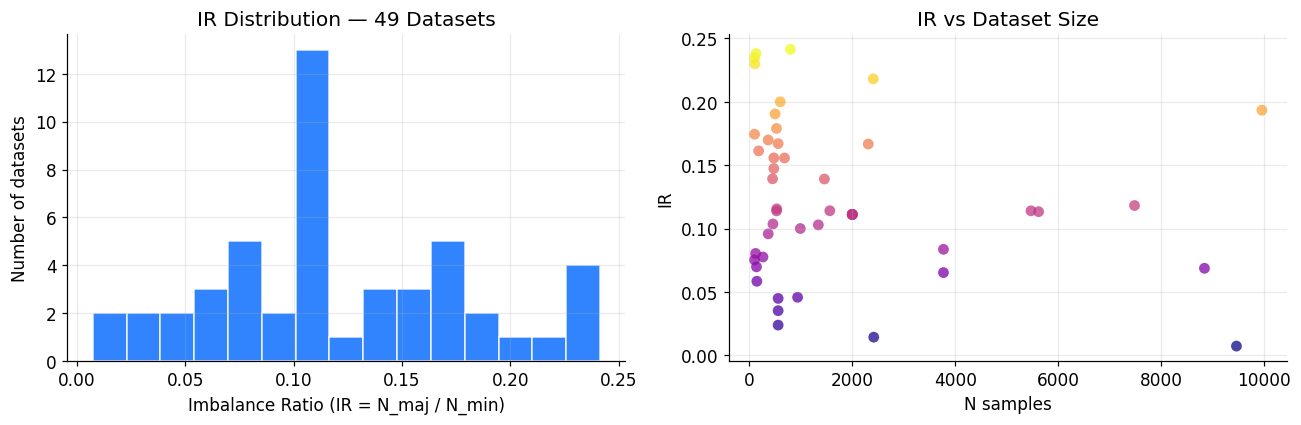

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets")

ds_meta = pd.DataFrame([{
    "dataset":    ds.name,
    "n_samples":  ds.X.shape[0],
    "n_features": ds.X.shape[1],
    "IR":         ds.imbalance_ratio,
} for ds in datasets]).sort_values("IR").reset_index(drop=True)

print(f"\nImbalance Ratio  — min: {ds_meta['IR'].min():.2f} | "
      f"median: {ds_meta['IR'].median():.2f} | max: {ds_meta['IR'].max():.2f}")
print(f"Samples          — min: {ds_meta['n_samples'].min()} | "
      f"median: {int(ds_meta['n_samples'].median())} | max: {ds_meta['n_samples'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ds_meta["IR"], bins=15, color="#0d6efd", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Imbalance Ratio (IR = N_maj / N_min)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("IR Distribution — 49 Datasets")

axes[1].scatter(ds_meta["n_samples"], ds_meta["IR"],
                c=ds_meta["IR"], cmap="plasma", s=50, alpha=0.75, edgecolors="none")
axes[1].set_xlabel("N samples"); axes[1].set_ylabel("IR")
axes[1].set_title("IR vs Dataset Size")

plt.tight_layout()
plt.savefig("results/figures/dataset_overview.png", bbox_inches="tight")
plt.show()

## 2 · The Structural Bias of Standard KNN

### 2.1 Theoretical argument

Consider a query point $x$ near the decision boundary with $r = N_{maj}/N_{min} \gg 1$.
Under a homogeneous Poisson process model, the expected distance to the $k$-th nearest
neighbour from class $c$ scales as:

$$\mathbb{E}[d_k^c] \propto \left(\frac{k}{N_c}\right)^{1/d}$$

**Even if both class densities are equal**, the majority class produces a closer rank-1
neighbour with high probability simply because $N_{maj} > N_{min}$.  
Standard KNN majority vote therefore has a systematic, non-stochastic bias toward the
majority class — one that grows with $r$ and cannot be eliminated by tuning $k$.

### 2.2 Empirical confirmation

We confirm this bias by examining how KNNOptK G-Mean degrades as IR increases:


Loaded: 24500 rows — 5 repetitions × 10-fold CV


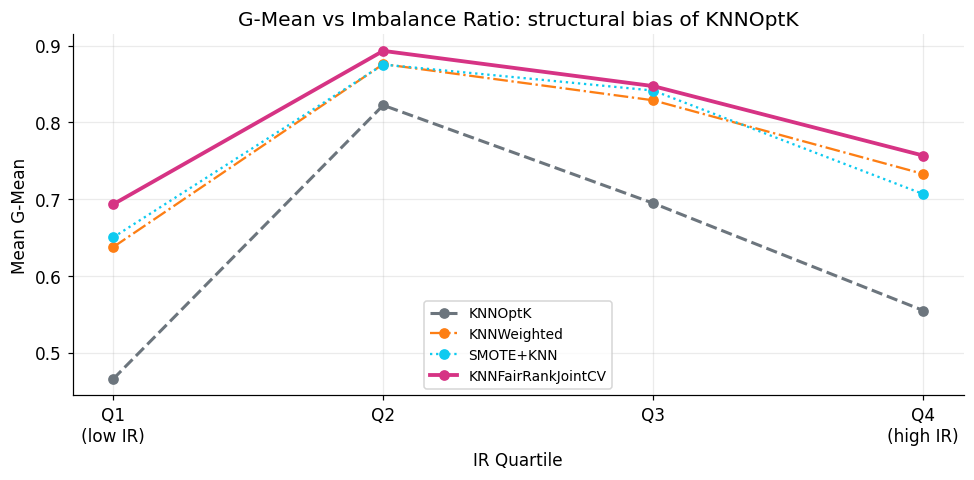

KNNOptK G-Mean by IR quartile:
  Q1
(IR ≤ 8.5)       : 0.4657
  Q2
(8.5–15)         : 0.8223
  Q3
(15–37)          : 0.6947
  Q4
(IR > 37)        : 0.5549


In [3]:
# Load benchmark — 5-rep file preferred (full run), fallback to 1-rep if still running
import os
_bench_5 = "results/tables/benchmark_5rep.csv"
_bench_1 = "results/tables/benchmark_1rep.csv"
if os.path.exists(_bench_5):
    bench = pd.read_csv(_bench_5)
    _reps_label = "5 repetitions × 10-fold CV"
else:
    bench = pd.read_csv(_bench_1)
    _reps_label = "1 rep × 10-fold CV (5-rep run still in progress)"
print(f"Loaded: {len(bench)} rows — {_reps_label}")

def compute_metrics(df):
    tp, tn, fp, fn = df["tp"], df["tn"], df["fp"], df["fn"]
    denom = np.sqrt(np.maximum(0, (tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)))
    mcc   = np.where(denom > 0, (tp*tn - fp*fn)/denom, 0.0)
    sens  = np.where(tp+fn > 0, tp/(tp+fn), 0.0)
    spec  = np.where(tn+fp > 0, tn/(tn+fp), 0.0)
    gmean = np.sqrt(sens * spec)
    prec  = np.where(tp+fp > 0, tp/(tp+fp), 0.0)
    f1    = np.where(prec+sens > 0, 2*prec*sens/(prec+sens), 0.0)
    out = df.copy()
    out["mcc"]=mcc; out["g_mean"]=gmean; out["f1"]=f1
    return out

bench  = compute_metrics(bench)
agg    = bench.groupby(["dataset","algorithm"])[["mcc","g_mean","f1","roc_auc","pr_auc"]].mean().reset_index()
agg_all   = agg[agg["algorithm"].isin(ALGOS)].copy()

agg_ir     = agg_all.merge(ds_meta[["dataset","IR"]], on="dataset", how="left")
agg_ir["IR_quartile"] = pd.qcut(
    agg_ir["IR"], q=4, labels=["Q1\n(IR ≤ 8.5)","Q2\n(8.5–15)","Q3\n(15–37)","Q4\n(IR > 37)"]
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for algo, ls, lw in [("KNNOptK","--",2), ("KNNWeighted","-.",1.5),
                     ("SMOTE+KNN",":",1.5), ("KNNFairRankJointCV","-",2.5)]:
    sub = agg_ir[agg_ir["algorithm"]==algo]
    means = sub.groupby("IR_quartile", observed=True)["g_mean"].mean()
    ax.plot(range(len(means)), means.values, marker="o",
            color=PALETTE[algo], linewidth=lw, linestyle=ls, label=algo)

ax.set_xticks(range(4))
ax.set_xticklabels(["Q1\n(low IR)","Q2","Q3","Q4\n(high IR)"])
ax.set_ylabel("Mean G-Mean"); ax.set_xlabel("IR Quartile")
ax.set_title("G-Mean vs Imbalance Ratio: structural bias of KNNOptK")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("results/figures/bias_by_ir.png", bbox_inches="tight")
plt.show()

print("KNNOptK G-Mean by IR quartile:")
for q, v in agg_ir[agg_ir["algorithm"]=="KNNOptK"].groupby("IR_quartile",observed=True)["g_mean"].mean().items():
    print(f"  {str(q):20s}: {v:.4f}")

\
## 3 · Theoretical Derivation: KNNFairRank

### 3.1 The fair-rank correction

Starting from the Poisson nearest-neighbour model, we want to find $k_{\text{eff}}$ such
that the $k_{\text{eff}}$-th majority neighbour is at the **same expected distance** as
the 1st minority neighbour:

$$\mathbb{E}[d_{k_{\text{eff}}}^{maj}] = \mathbb{E}[d_1^{min}]$$

Substituting the scaling law and raising both sides to the power $d$:

$$\left(\frac{k_{\text{eff}}}{N_{maj}}\right)^{1/d} = \left(\frac{1}{N_{min}}\right)^{1/d}
\;\implies\;
\frac{k_{\text{eff}}}{N_{maj}} = \frac{1}{N_{min}}
\;\implies\; \boxed{k_{\text{eff}} = \frac{N_{maj}}{N_{min}} = r}$$

The dimension $d$ **cancels exactly** — the correction factor is dimension-free.

### 3.2 Multi-rank voting

Rather than a single comparison, we aggregate $n_{votes}$ rank-corrected comparisons:

$$\text{for } i = 1,\ldots,n_{votes}: \quad \text{vote minority if } d_i^{min} < d_{i \cdot k_{\text{eff}}}^{maj}$$

Predict minority if the fraction of votes exceeding 0.5.

### 3.3 Calibrated correction exponent (KNNFairRankCV / JointCV)

The uniform-density assumption may not hold locally. We introduce:

$$k_{\text{eff}} = r^\alpha, \quad \alpha \in \{0.25,\, 0.5,\, 0.75,\, 1.0\}$$

- $\alpha = 1$: theoretical value — full correction
- $\alpha < 1$: damped correction for clustered minorities

**KNNFairRankCV** selects $\alpha$ via inner 3-fold stratified CV on G-Mean.  
**KNNFairRankJointCV** selects $(n_{votes}, \alpha)$ jointly — the efficiency trick is that
varying $\alpha$ after fitting costs nothing (it only patches `_r = r^α`).

### 3.4 LOO Jackknife (KNNFairRankJackknife)

A noisy minority neighbour can dominate one vote. Jackknife runs $k_{probe}$ LOO trials,
each excluding one minority rank, then averages the vote fractions — diluting outlier influence.


## 4 · Algorithm Implementations

### 4.1 KNNClassifierFast & KNNOptK

In [4]:
from src.algorithms.baseline.knn_base import KNNClassifierFast, KNNOptK

# Core: adapted from rushter/MLAlgorithms (vectorised cdist, sklearn API added)
# KNNOptK: selects k from odd values {1, 3, ..., sqrt(n)} via inner 3-fold CV
# Scoring: balanced_accuracy (appropriate for imbalanced problems)

# Quick smoke test
from sklearn.datasets import make_classification
X_d, y_d = make_classification(n_samples=300, n_features=8, random_state=42)
opt = KNNOptK().fit(X_d, y_d)
print(f"KNNOptK — k_range: {opt.k_range_[:6]}... → best k = {opt.best_k_}")

KNNOptK — k_range: [1, 3, 5, 7, 9, 11]... → best k = 11


### 4.2 KNNWeighted

In [5]:
from src.algorithms.baseline.knn_weighted import KNNWeighted

# Simplest imbalance-aware KNN: vote weight = N_total / (n_classes * N_c)
# Binary case: minority votes amplified by r = N_maj / N_min
# Serves as the key sanity-check baseline: if FairRank ≤ KNNWeighted,
# the rank-correction mechanism adds nothing beyond frequency weighting.

wknn = KNNWeighted(k=5).fit(X_d, y_d)
print("KNNWeighted class weights:", dict(zip(wknn.classes_, wknn._class_weights.round(3))))

KNNWeighted class weights: {np.int64(0): np.float64(0.993), np.int64(1): np.float64(1.007)}


### 4.3 KNNFairRank — core proposal

In [6]:
from src.algorithms.fair_rank.core.knn_fair_rank import KNNFairRank

# Synthetic heavily imbalanced dataset (IR ≈ 19:1)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, weights=[0.95, 0.05],
    n_informative=10, random_state=42
)
n_maj, n_min = int(np.sum(y_imb==0)), int(np.sum(y_imb==1))
print(f"N_maj={n_maj}, N_min={n_min}, r={n_maj/n_min:.1f}")

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2,
                                            stratify=y_imb, random_state=SEED)
sc = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)

fr = KNNFairRank().fit(X_tr_s, y_tr)
print(f"\nFitted KNNFairRank:")
print(f"  k_eff = round(r) = {int(round(fr._r))}")
print(f"  k_min (minority neighbours fetched) = {fr._k_min_eff}")
print(f"  k_maj (majority neighbours fetched) = {fr._k_maj_eff}")
print(f"  n_votes = {fr._n_votes}")

N_maj=1888, N_min=112, r=16.9

Fitted KNNFairRank:
  k_eff = round(r) = 17
  k_min (minority neighbours fetched) = 10
  k_maj (majority neighbours fetched) = 95
  n_votes = 5


### 4.4 KNNFairRankCV, KNNFairRankJointCV, KNNFairRankJackknife

In [7]:
from src.algorithms.fair_rank.core.knn_fair_rank_c import KNNFairRankCV
from src.algorithms.fair_rank.ensemble.knn_fair_rank_joint_cv import KNNFairRankJointCV
from src.algorithms.fair_rank.resampling.knn_fair_rank_jackknife import KNNFairRankJackknife
from src.evaluation.metrics import geometric_mean
from sklearn.metrics import matthews_corrcoef
from imblearn.over_sampling import SMOTE

cv_fr = KNNFairRankCV().fit(X_tr_s, y_tr)
print(f"KNNFairRankCV    — best α = {cv_fr.best_alpha_}")

jcv   = KNNFairRankJointCV().fit(X_tr_s, y_tr)
print(f"KNNFairRankJointCV — best (n_votes={jcv.best_n_votes_}, α={jcv.best_alpha_})")

jk    = KNNFairRankJackknife().fit(X_tr_s, y_tr)
print(f"KNNFairRankJackknife — k_probe = {jk._k_probe}")

# SMOTE baseline
X_sm, y_sm = SMOTE(k_neighbors=5, random_state=SEED).fit_resample(X_tr_s, y_tr)
smote_knn = KNNOptK().fit(X_sm, y_sm)

print("\n── Single-dataset comparison (IR≈19, synthetic) ────────────────")
print(f"{'Algorithm':30s}  {'G-Mean':>8}  {'MCC':>8}")
print("─"*52)
for name, clf in [
    ("KNNOptK",             KNNOptK()),
    ("KNNWeighted (k=5)",   KNNWeighted(k=5)),
    ("SMOTE+KNN",           smote_knn),
    ("KNNFairRank",         fr),
    ("KNNFairRankCV",       cv_fr),
    ("KNNFairRankJointCV",  jcv),
    ("KNNFairRankJackknife",jk),
]:
    if name == "SMOTE+KNN":
        y_p = clf.predict(X_te_s)
    else:
        clf.fit(X_tr_s, y_tr)
        y_p = clf.predict(X_te_s)
    gm  = geometric_mean(y_te, y_p)
    mcc = matthews_corrcoef(y_te, y_p)
    print(f"  {name:28s}  {gm:8.4f}  {mcc:8.4f}")

KNNFairRankCV    — best α = 1.0
KNNFairRankJointCV — best (n_votes=10, α=1.0)
KNNFairRankJackknife — k_probe = None

── Single-dataset comparison (IR≈19, synthetic) ────────────────
Algorithm                         G-Mean       MCC
────────────────────────────────────────────────────
  KNNOptK                         0.5581    0.3564
  KNNWeighted (k=5)               0.7499    0.3367
  SMOTE+KNN                       0.7709    0.4382
  KNNFairRank                     0.8191    0.3227
  KNNFairRankCV                   0.8191    0.3227
  KNNFairRankJointCV              0.8480    0.3698
  KNNFairRankJackknife            0.8296    0.3795


## 5 · Experimental Setup

| Parameter | Value |
|:---|:---|
| Outer CV strategy | Repeated Stratified K-Fold |
| Folds | 10 |
| Repetitions | **5** (10-fold × 5 = 50 splits per dataset) |
| Random seed | 42 |
| Feature scaling | StandardScaler fitted **on train fold only** |
| Primary metric | **G-Mean** = √(Sensitivity × Specificity) |
| Secondary metrics | MCC, F1, ROC-AUC, PR-AUC |
| Statistical framework | Demšar (2006) |

**Why G-Mean as primary metric?**  
G-Mean penalises a classifier that ignores either class equally — a classifier predicting
all majority achieves G-Mean = 0. MCC is reported as secondary but interpreted with
caution: under moderate imbalance, majority-biased classifiers can still achieve high MCC.

**SMOTE baseline:** SMOTE ($k=5$, auto-sampling to 1:1) + KNNOptK. This is the standard
re-sampling state-of-the-art. KNNFairRank operates entirely at prediction time — no
synthetic data generated, no memory overhead.


## 6 · Results

### 6.1 Mean performance across 40 datasets (degenerate excluded)

In [8]:
summary = agg_all.groupby("algorithm")[["mcc","g_mean","f1","roc_auc","pr_auc"]].mean()
summary.columns = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
summary = summary.loc[sorted(summary.index, key=lambda a: -summary.loc[a,"G-Mean"])]
print("Mean performance (40 datasets, 5-rep × 10-fold CV, 10 algorithms):")
print(summary.to_string(float_format="{:.4f}".format))

Mean performance (40 datasets, 5-rep × 10-fold CV, 10 algorithms):
                                 MCC  G-Mean     F1  ROC-AUC  PR-AUC
algorithm                                                           
KNNFairRankOptVotes           0.5034  0.7961 0.5326   0.8472  0.4520
KNNFairRankJointCV            0.5453  0.7955 0.5764   0.8529  0.5188
KNNFairRankCV                 0.5246  0.7894 0.5543   0.8590  0.5328
KNNFairRank                   0.4724  0.7857 0.5023   0.8555  0.4880
KNNFairRankJackknife          0.5018  0.7806 0.5323   0.8677  0.5452
KNNFairRankTopoJointBootstrap 0.5041  0.7666 0.5385   0.8461  0.5171
KNNWeighted                   0.5121  0.7661 0.5581   0.8299  0.5961
SMOTE+KNN                     0.5234  0.7660 0.5639   0.8437  0.5685
KNNFairRankEnsemble           0.5452  0.7179 0.5754   0.8780  0.6490
KNNOptK                       0.5240  0.6310 0.5511   0.7909  0.5453


### 6.2 G-Mean comparison

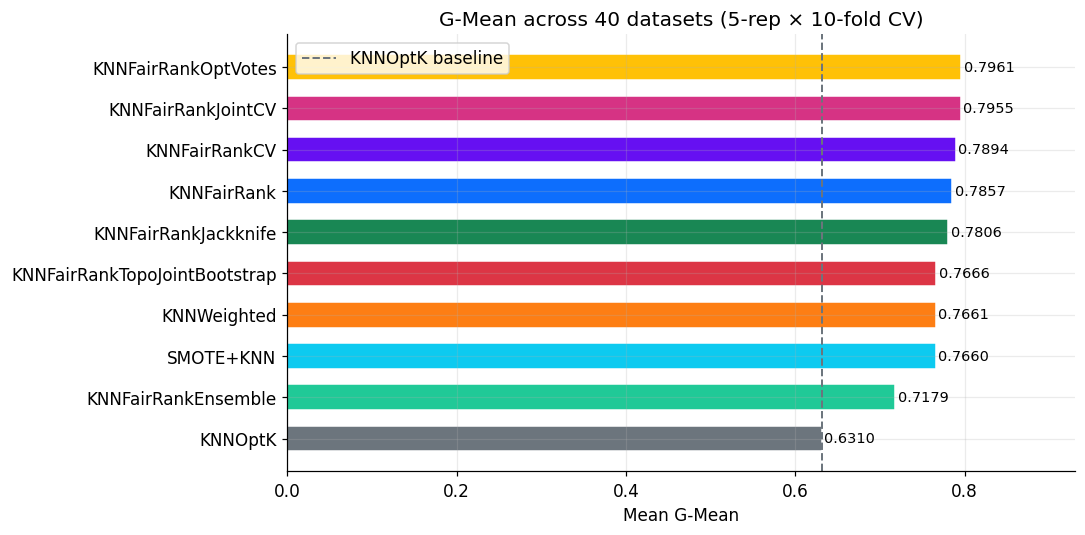

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
gm_means = agg_all.groupby("algorithm")["g_mean"].mean().sort_values()
colors   = [PALETTE.get(a,"#adb5bd") for a in gm_means.index]

bars = ax.barh(gm_means.index, gm_means.values, color=colors, edgecolor="white", height=0.62)
ax.axvline(gm_means["KNNOptK"], color="#6c757d", linestyle="--", lw=1.3, label="KNNOptK baseline")
for bar, val in zip(bars, gm_means.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9.5)

ax.set_xlabel("Mean G-Mean"); ax.set_title("G-Mean across 40 datasets (5-rep × 10-fold CV)")
ax.set_xlim(0, 0.93); ax.legend()
plt.tight_layout()
plt.savefig("results/figures/gmean_bar.png", bbox_inches="tight")
plt.show()

### 6.3 ROC-AUC comparison

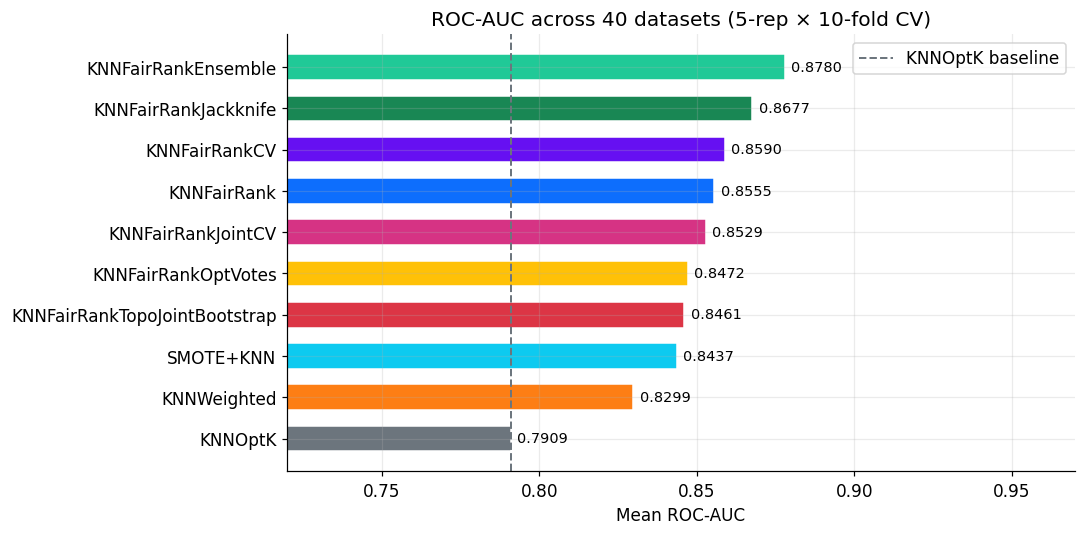

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
roc_means = agg_all.groupby("algorithm")["roc_auc"].mean().sort_values()
colors2   = [PALETTE.get(a,"#adb5bd") for a in roc_means.index]

bars2 = ax.barh(roc_means.index, roc_means.values, color=colors2, edgecolor="white", height=0.62)
ax.axvline(roc_means["KNNOptK"], color="#6c757d", linestyle="--", lw=1.3, label="KNNOptK baseline")
for bar, val in zip(bars2, roc_means.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9.5)

ax.set_xlabel("Mean ROC-AUC"); ax.set_title("ROC-AUC across 40 datasets (5-rep × 10-fold CV)")
ax.set_xlim(0.72, 0.97); ax.legend()
plt.tight_layout()
plt.savefig("results/figures/rocauc_bar.png", bbox_inches="tight")
plt.show()

### 6.4 Performance by imbalance ratio quartile

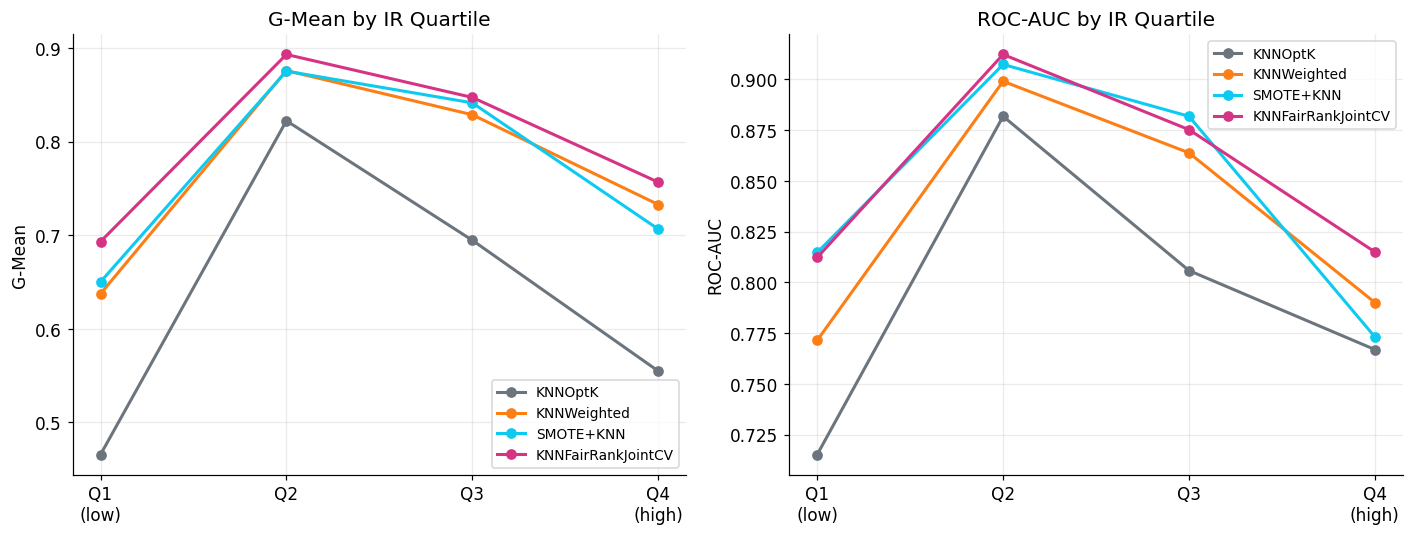

G-Mean Q1 → Q4 degradation:
  KNNOptK                       : 0.466 → 0.555  (Δ=+0.089)
  KNNWeighted                   : 0.637 → 0.733  (Δ=+0.095)
  SMOTE+KNN                     : 0.650 → 0.707  (Δ=+0.056)
  KNNFairRankJointCV            : 0.693 → 0.757  (Δ=+0.064)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
focus = ["KNNOptK","KNNWeighted","SMOTE+KNN","KNNFairRankJointCV"]

for ax, metric, ylabel in [(axes[0],"g_mean","G-Mean"), (axes[1],"roc_auc","ROC-AUC")]:
    for algo in focus:
        sub   = agg_ir[agg_ir["algorithm"]==algo]
        means = sub.groupby("IR_quartile", observed=True)[metric].mean()
        ax.plot(range(len(means)), means.values, marker="o",
                color=PALETTE[algo], linewidth=2, label=algo)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Q1\n(low)","Q2","Q3","Q4\n(high)"])
    ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    ax.set_title(f"{ylabel} by IR Quartile")

plt.tight_layout()
plt.savefig("results/figures/by_ir_quartile.png", bbox_inches="tight")
plt.show()

# Quantify degradation
print("G-Mean Q1 → Q4 degradation:")
for algo in focus:
    sub   = agg_ir[agg_ir["algorithm"]==algo]
    means = sub.groupby("IR_quartile", observed=True)["g_mean"].mean()
    print(f"  {algo:30s}: {means.iloc[0]:.3f} → {means.iloc[-1]:.3f}  (Δ={means.iloc[-1]-means.iloc[0]:+.3f})")

## 7 · Statistical Validation

We follow the **Demšar (2006)** protocol:

1. **Friedman test** — global null: all algorithms perform equally.
2. **Post-hoc Wilcoxon signed-rank** (per-dataset differences) with **Holm correction** — pairwise vs each baseline.
3. **Nemenyi Critical Difference** — determines if the top-ranked algorithm is statistically separated from the runner-up.


In [12]:
METRICS = ["mcc","g_mean","f1","roc_auc","pr_auc"]

def avg_ranks(pivot):
    return pivot.rank(axis=1, ascending=False).mean()

def pw_wilcoxon(pivot, baseline):
    others = [c for c in pivot.columns if c != baseline]
    pvals  = []
    for o in others:
        diff = pivot[o] - pivot[baseline]
        pvals.append(1.0 if diff.abs().sum()==0 else wilcoxon(pivot[o], pivot[baseline])[1])
    _, p_corr, _, _ = multipletests(pvals, method="holm")
    return list(zip(others, pvals, p_corr))

def nemenyi_cd(k, n):
    q = {2:1.960,3:2.344,4:2.569,5:2.728,6:2.850,7:2.949,
         8:3.031,9:3.102,10:3.164}.get(k, 2.949)
    return q * np.sqrt(k*(k+1)/(6*n))

pivots = {m: agg_all.pivot(index="dataset", columns="algorithm", values=m).dropna()
          for m in METRICS}

k  = len(ALGOS)
n  = len(pivots["g_mean"])
CD = nemenyi_cd(k, n)
print(f"Algorithms: {k}  |  Datasets: {n}  |  Nemenyi CD = {CD:.3f}")

Algorithms: 10  |  Datasets: 49  |  Nemenyi CD = 1.935


### 7.1 Friedman test

In [13]:
print(f"{'Metric':10s}  {'χ²':>8}  {'p-value':>12}  {'Significant?':>14}")
print("─"*50)
for m in METRICS:
    stat, p = friedmanchisquare(*[pivots[m][c].values for c in pivots[m].columns])
    print(f"{m.upper():10s}  {stat:8.2f}  {p:12.2e}  {'*** YES' if p<0.05 else 'no':>14}")

Metric            χ²       p-value    Significant?
──────────────────────────────────────────────────
MCC            60.16      1.25e-09         *** YES
G_MEAN         72.31      5.34e-12         *** YES
F1             65.44      1.19e-10         *** YES
ROC_AUC       127.20      4.47e-23         *** YES
PR_AUC        186.65      2.06e-35         *** YES


### 7.2 Average ranks

In [14]:
rank_df = pd.DataFrame({m: avg_ranks(pivots[m]) for m in METRICS})
rank_df.columns = [m.upper() for m in METRICS]
rank_df = rank_df.sort_values("G_MEAN")
print("Average ranks  (1 = best, 10 = worst):")
print(rank_df.round(3).to_string())

Average ranks  (1 = best, 10 = worst):
                                 MCC  G_MEAN     F1  ROC_AUC  PR_AUC
algorithm                                                           
KNNFairRankJointCV             4.051   3.684  4.112    5.959   6.398
KNNFairRankOptVotes            6.255   4.480  6.561    7.184   8.418
KNNFairRankCV                  4.888   4.490  4.959    4.551   5.673
SMOTE+KNN                      5.204   5.163  4.796    5.327   4.316
KNNFairRankJackknife           5.643   5.459  5.724    3.959   4.541
KNNWeighted                    6.173   5.561  5.765    5.622   3.633
KNNFairRankTopoJointBootstrap  6.337   5.724  6.133    6.520   6.571
KNNFairRank                    7.582   5.837  7.816    5.786   7.622
KNNFairRankEnsemble            4.245   6.571  4.082    2.276   1.898
KNNOptK                        4.622   8.031  5.051    7.816   5.929


### 7.3 Rank visualisations

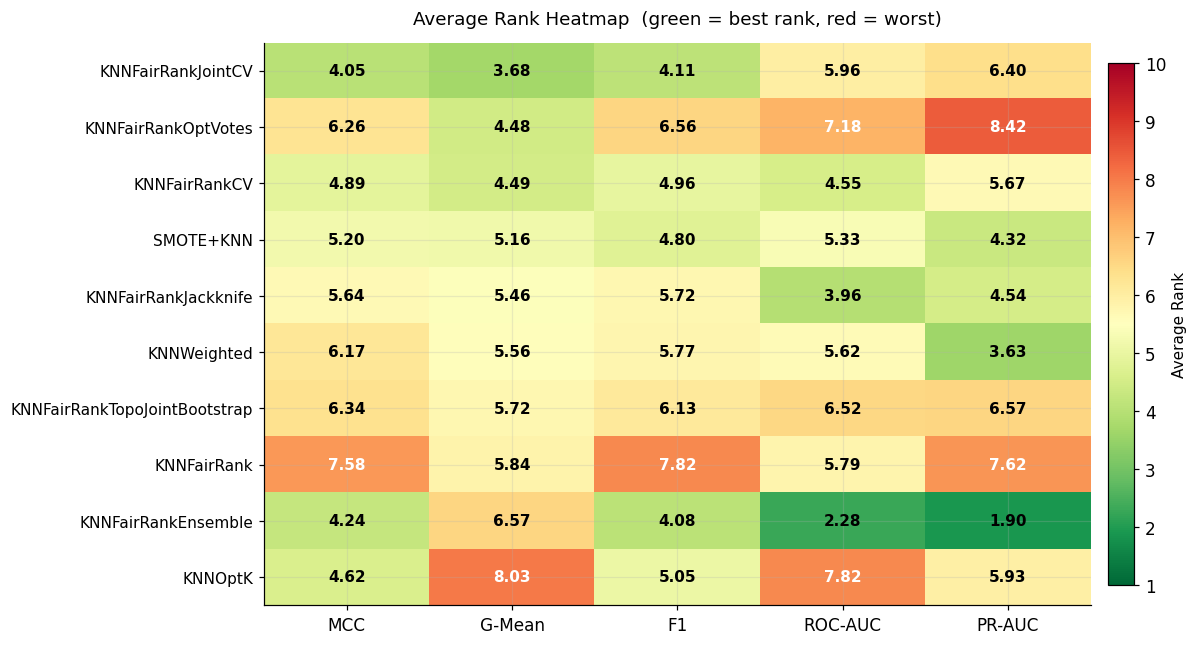

In [15]:
# ── Rank heatmap: algorithms × metrics ───────────────────────────────────────
rank_df_plot = pd.DataFrame({m: avg_ranks(pivots[m]) for m in METRICS})
rank_df_plot.columns = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
rank_df_plot = rank_df_plot.loc[
    sorted(rank_df_plot.index, key=lambda a: rank_df_plot.loc[a,"G-Mean"])
]

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(rank_df_plot.values, cmap="RdYlGn_r", aspect="auto",
               vmin=1, vmax=len(ALGOS))

# Annotate each cell with the rank value
for i in range(rank_df_plot.shape[0]):
    for j in range(rank_df_plot.shape[1]):
        val = rank_df_plot.values[i, j]
        colour = "white" if val > 7.0 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, fontweight="bold", color=colour)

ax.set_xticks(range(len(rank_df_plot.columns)))
ax.set_xticklabels(rank_df_plot.columns, fontsize=11)
ax.set_yticks(range(len(rank_df_plot.index)))
ax.set_yticklabels(rank_df_plot.index, fontsize=10)
ax.set_title("Average Rank Heatmap  (green = best rank, red = worst)", fontsize=12, pad=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Average Rank", fontsize=10)
cbar.set_ticks(list(range(1, len(ALGOS) + 1)))

plt.tight_layout()
plt.savefig("results/figures/rank_heatmap.png", bbox_inches="tight")
plt.show()

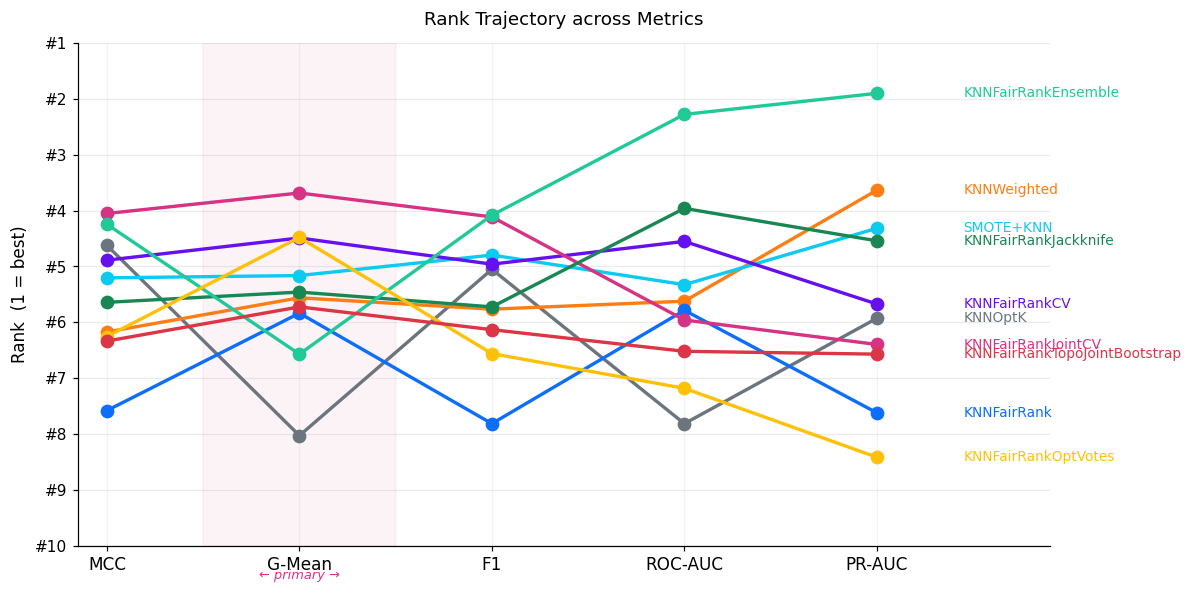

In [16]:
# ── Bump chart: rank trajectory across metrics ────────────────────────────────
METRICS_LABEL = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
x = range(len(METRICS))

fig, ax = plt.subplots(figsize=(11, 5.5))

for algo in ALGOS:
    ranks = [avg_ranks(pivots[m])[algo] for m in METRICS]
    color = PALETTE[algo]
    ax.plot(x, ranks, marker="o", color=color, linewidth=2.2,
            markersize=8, label=algo, zorder=3)
    # Label at the right end
    ax.text(len(METRICS) - 0.55, ranks[-1], algo,
            va="center", ha="left", fontsize=9, color=color)

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels(METRICS_LABEL, fontsize=11)
ax.set_yticks(range(1, len(ALGOS) + 1))
ax.set_yticklabels([f"#{i}" for i in range(1, len(ALGOS) + 1)], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(-0.15, len(METRICS) - 0.1)
ax.set_ylabel("Rank  (1 = best)", fontsize=11)
ax.set_title("Rank Trajectory across Metrics", fontsize=12, pad=12)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", alpha=0.15)

# Shade the background of the G-Mean column (primary metric)
ax.axvspan(0.5, 1.5, color="#d63384", alpha=0.06, zorder=0, label="Primary metric")
ax.text(1, len(ALGOS) + 0.6, "← primary →", ha="center",
        fontsize=8.5, color="#d63384", style="italic")

plt.tight_layout()
plt.savefig("results/figures/rank_bump_chart.png", bbox_inches="tight")
plt.show()

### 7.3 Wilcoxon vs KNNOptK (Holm-corrected)

In [17]:
print("Wilcoxon signed-rank vs KNNOptK (Holm α=0.05):")
for m in ["g_mean","roc_auc","mcc","f1"]:
    res = pw_wilcoxon(pivots[m], "KNNOptK")
    n_sig = sum(1 for _,_,pc in res if pc < 0.05)
    print(f"\n  {m.upper()} — significant: {n_sig}/{len(res)}")
    for o, pr, pc in sorted(res, key=lambda x: x[2]):
        diff  = agg_all[agg_all["algorithm"]==o][m].mean() - agg_all[agg_all["algorithm"]=="KNNOptK"][m].mean()
        tick  = "✓" if pc < 0.05 else "✗"
        print(f"    {tick} {o:30s}: p_corr={pc:.4f}  Δ={diff:+.4f}")

Wilcoxon signed-rank vs KNNOptK (Holm α=0.05):

  G_MEAN — significant: 9/9
    ✓ KNNFairRankJointCV            : p_corr=0.0000  Δ=+0.1645
    ✓ KNNWeighted                   : p_corr=0.0000  Δ=+0.1351
    ✓ KNNFairRankOptVotes           : p_corr=0.0000  Δ=+0.1651
    ✓ KNNFairRankCV                 : p_corr=0.0000  Δ=+0.1585
    ✓ SMOTE+KNN                     : p_corr=0.0000  Δ=+0.1351
    ✓ KNNFairRank                   : p_corr=0.0000  Δ=+0.1547
    ✓ KNNFairRankJackknife          : p_corr=0.0000  Δ=+0.1497
    ✓ KNNFairRankTopoJointBootstrap : p_corr=0.0000  Δ=+0.1357
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0869

  ROC_AUC — significant: 9/9
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0871
    ✓ KNNFairRankCV                 : p_corr=0.0000  Δ=+0.0681
    ✓ KNNWeighted                   : p_corr=0.0000  Δ=+0.0390
    ✓ KNNFairRankJackknife          : p_corr=0.0000  Δ=+0.0768
    ✓ SMOTE+KNN                     : p_corr=0.0000  Δ=+0.0528
    ✓ KNNFai

### 7.4 Wilcoxon vs SMOTE+KNN (Holm-corrected)

In [18]:
print("Wilcoxon signed-rank vs SMOTE+KNN (Holm α=0.05):")
for m in ["g_mean","roc_auc"]:
    res = pw_wilcoxon(pivots[m], "SMOTE+KNN")
    n_sig = sum(1 for _,_,pc in res if pc < 0.05)
    print(f"\n  {m.upper()} — significant: {n_sig}/{len(res)}")
    for o, pr, pc in sorted(res, key=lambda x: x[2]):
        diff  = agg_all[agg_all["algorithm"]==o][m].mean() - agg_all[agg_all["algorithm"]=="SMOTE+KNN"][m].mean()
        label = "BETTER" if diff > 0 else "worse"
        tick  = "✓" if pc < 0.05 else "✗"
        print(f"    {tick} {o:30s}: p_corr={pc:.4f}  Δ={diff:+.4f}  [{label}]")

Wilcoxon signed-rank vs SMOTE+KNN (Holm α=0.05):

  G_MEAN — significant: 1/9
    ✓ KNNOptK                       : p_corr=0.0000  Δ=-0.1351  [worse]
    ✗ KNNFairRankEnsemble           : p_corr=0.0716  Δ=-0.0481  [worse]
    ✗ KNNFairRankJointCV            : p_corr=0.1355  Δ=+0.0295  [BETTER]
    ✗ KNNFairRankOptVotes           : p_corr=0.7140  Δ=+0.0301  [BETTER]
    ✗ KNNFairRank                   : p_corr=1.0000  Δ=+0.0196  [BETTER]
    ✗ KNNFairRankCV                 : p_corr=1.0000  Δ=+0.0234  [BETTER]
    ✗ KNNFairRankJackknife          : p_corr=1.0000  Δ=+0.0146  [BETTER]
    ✗ KNNFairRankTopoJointBootstrap : p_corr=1.0000  Δ=+0.0006  [BETTER]
    ✗ KNNWeighted                   : p_corr=1.0000  Δ=+0.0001  [BETTER]

  ROC_AUC — significant: 3/9
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0343  [BETTER]
    ✓ KNNOptK                       : p_corr=0.0000  Δ=-0.0528  [worse]
    ✓ KNNFairRankJackknife          : p_corr=0.0432  Δ=+0.0240  [BETTER]
    ✗ KNNFairRankCV

### 7.5 Critical Difference diagram

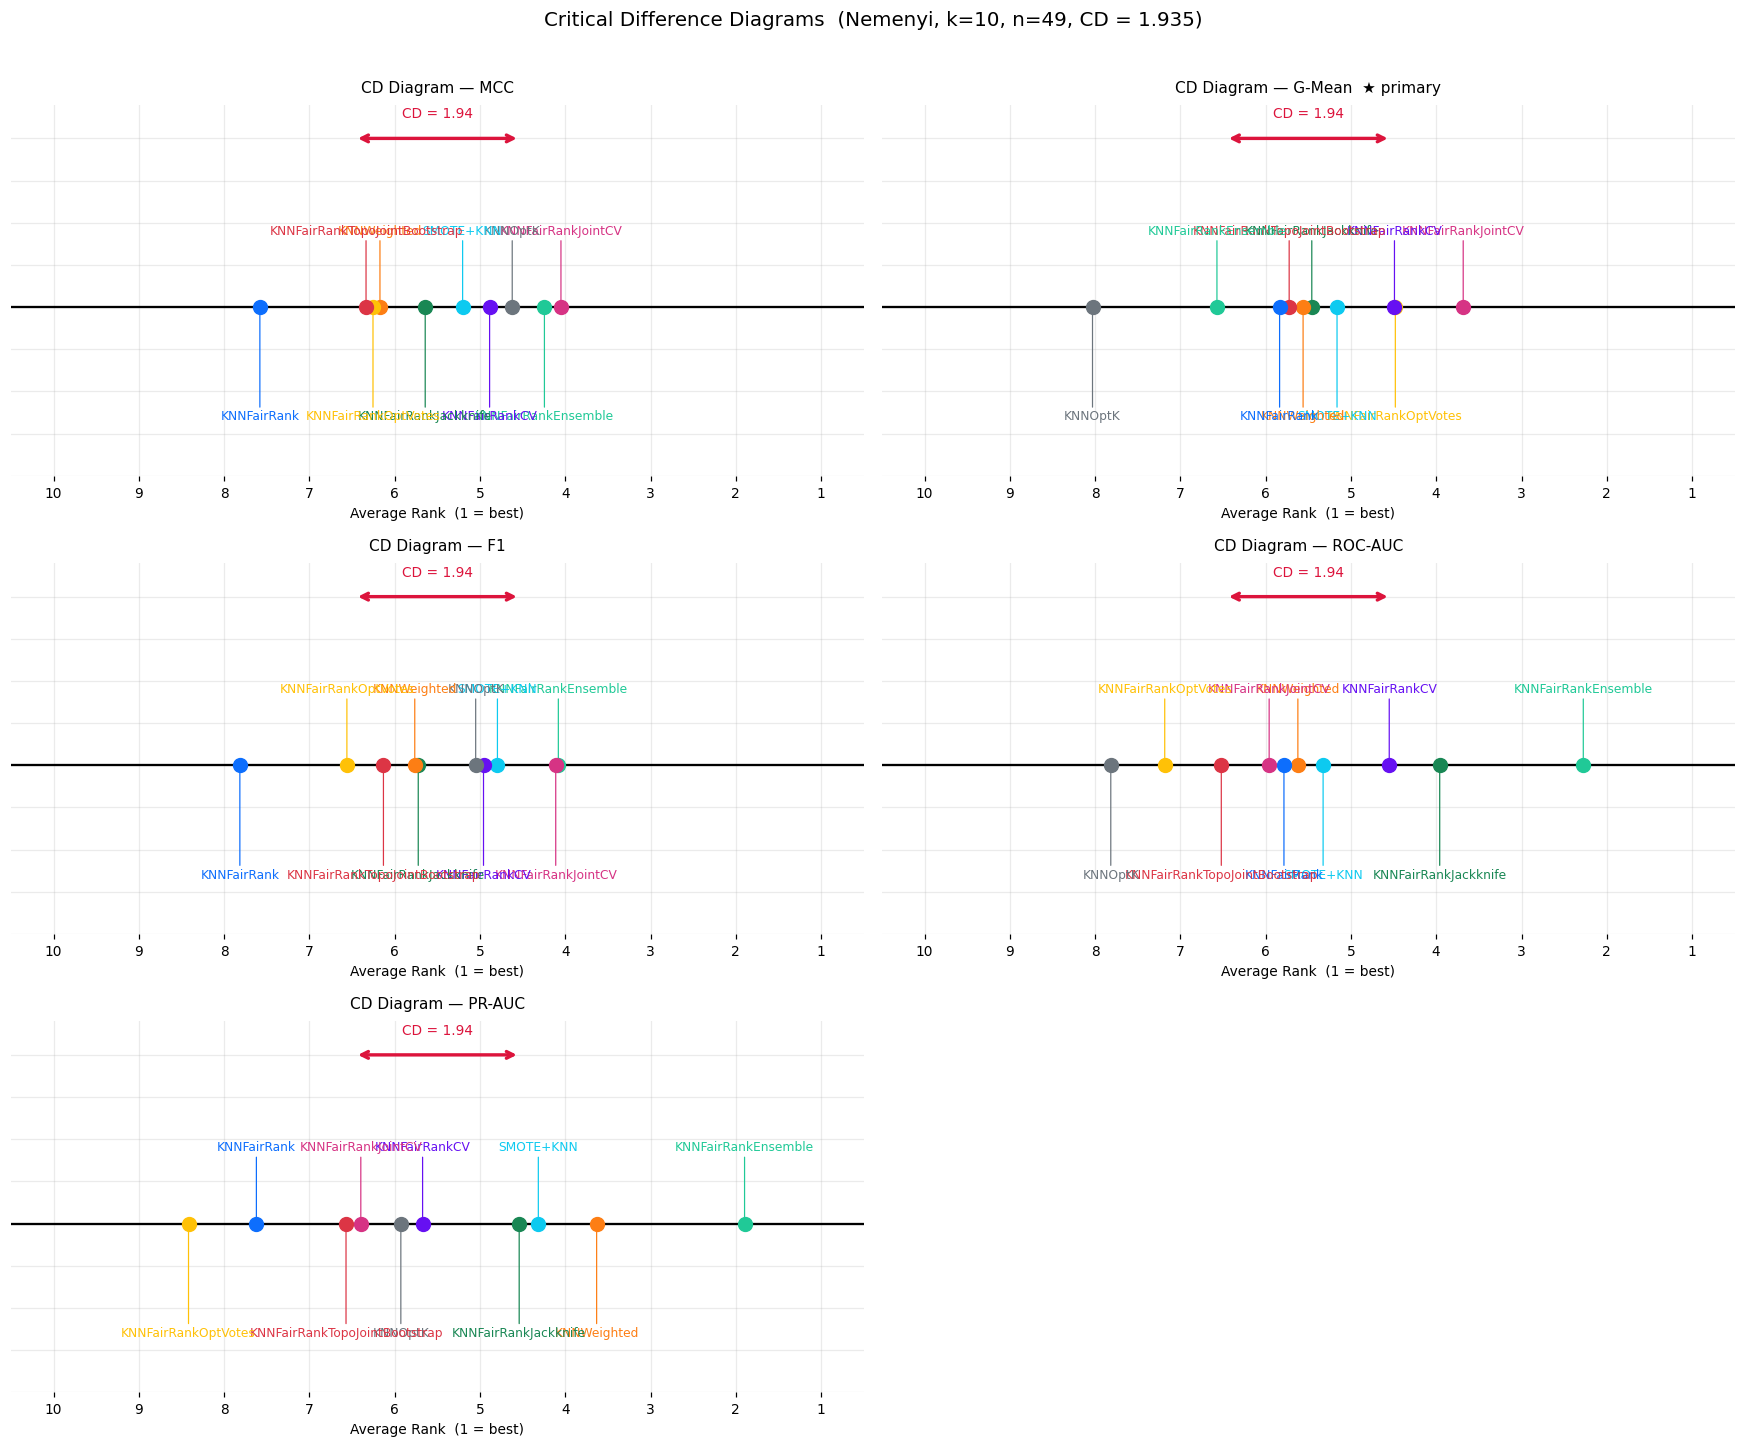

Metric      Best algorithm                   Rank      Gap    Separated?
──────────────────────────────────────────────────────────────────────
MCC         KNNFairRankJointCV               4.05    0.194            no
G-Mean      KNNFairRankJointCV               3.68    0.796            no
F1          KNNFairRankEnsemble              4.08    0.031            no
ROC-AUC     KNNFairRankEnsemble              2.28    1.684            no
PR-AUC      KNNFairRankEnsemble              1.90    1.735            no


In [19]:
# ── Critical Difference diagrams — all 5 metrics ─────────────────────────────
def draw_cd_full(ax, ranks_s, cd, title):
    ranks = ranks_s.sort_values()
    n     = len(ranks)
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-1.0, 1.2)
    ax.invert_xaxis()
    ax.axhline(0, color="black", lw=1.5)
    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels([str(i) for i in range(1, n + 1)], fontsize=9)
    for spine in ["left","right","bottom"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

    # CD bar
    mid = (n + 1) / 2
    ax.annotate("", xy=(mid - cd/2, 1.0), xytext=(mid + cd/2, 1.0),
                arrowprops=dict(arrowstyle="<->", color="crimson", lw=2.2))
    ax.text(mid, 1.12, f"CD = {cd:.2f}", ha="center", color="crimson", fontsize=9)

    # Algorithms
    for i, (name, rank) in enumerate(ranks.items()):
        c  = PALETTE.get(name, "#adb5bd")
        yo = 0.45 if i % 2 == 0 else -0.65
        ax.plot([rank], [0], "o", color=c, ms=9, zorder=5, clip_on=False)
        ax.annotate(
            name, xy=(rank, 0), xytext=(rank, yo),
            ha="center", va="center", fontsize=8, color=c,
            arrowprops=dict(arrowstyle="-", color=c, lw=0.8, shrinkA=0, shrinkB=3),
        )

    ax.set_xlabel("Average Rank  (1 = best)", fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes_flat = axes.flatten()

for ax, (m, label) in zip(axes_flat, [
    ("mcc",     "MCC"),
    ("g_mean",  "G-Mean  ★ primary"),
    ("f1",      "F1"),
    ("roc_auc", "ROC-AUC"),
    ("pr_auc",  "PR-AUC"),
]):
    draw_cd_full(ax, avg_ranks(pivots[m]), CD, f"CD Diagram — {label}")

# Hide the unused 6th subplot
axes_flat[-1].set_visible(False)

plt.suptitle(f"Critical Difference Diagrams  (Nemenyi, k={k}, n={n}, CD = {CD:.3f})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/cd_all_metrics.png", bbox_inches="tight")
plt.show()

# Print summary
print(f"{'Metric':10s}  {'Best algorithm':30s}  {'Rank':>5}  {'Gap':>7}  {'Separated?':>12}")
print("─"*70)
for m, label in [("mcc","MCC"),("g_mean","G-Mean"),("f1","F1"),("roc_auc","ROC-AUC"),("pr_auc","PR-AUC")]:
    r    = avg_ranks(pivots[m]).sort_values()
    gap  = list(r.values)[1] - list(r.values)[0]
    star = "★ YES" if gap > CD else "no"
    print(f"{label:10s}  {list(r.index)[0]:30s}  {list(r.values)[0]:5.2f}  {gap:7.3f}  {star:>12}")

---
## 8 · Degenerate Dataset Analysis  *(Exploratory)*

Nine datasets were excluded from the main analysis because their minority class
contains fewer than `2 × 10 = 20` samples, making 10-fold stratified CV unreliable
(some test folds contain zero minority examples).

We benchmark all 10 algorithms on this subset using the same CV scheme as the main run
and report **descriptive statistics only** — with n = 9 datasets there is no statistical
power for Wilcoxon or Friedman tests.

**Key question:** does SMOTE hold a structural advantage when the minority class is
extremely small, as theory predicts?


Loaded: benchmark_5rep_degenerate.csv — 9 datasets · 10 algorithms · 10-fold × 5 reps

Mean performance on 9 degenerate datasets (descriptive only):
                                  MCC  G-Mean      F1  ROC-AUC  PR-AUC
algorithm                                                             
KNNFairRankJointCV             0.4046  0.7067  0.4394   0.7860  0.3630
KNNWeighted                    0.4175  0.7066  0.4572   0.7784  0.4606
KNNFairRankOptVotes            0.3417  0.7012  0.3711   0.7827  0.2974
KNNFairRank                    0.3374  0.6966  0.3642   0.8103  0.4130
KNNFairRankJackknife           0.3922  0.6835  0.4231   0.8202  0.4848
KNNFairRankCV                  0.3549  0.6765  0.3866   0.8041  0.4310
SMOTE+KNN                      0.4085  0.6317  0.4340   0.8101  0.4761
KNNFairRankTopoJointBootstrap  0.3283  0.5750  0.3733   0.7650  0.4018
KNNFairRankEnsemble            0.4061  0.5313  0.4325   0.8363  0.5726
KNNOptK                        0.3694  0.4538  0.3910   0.7254  0.4113

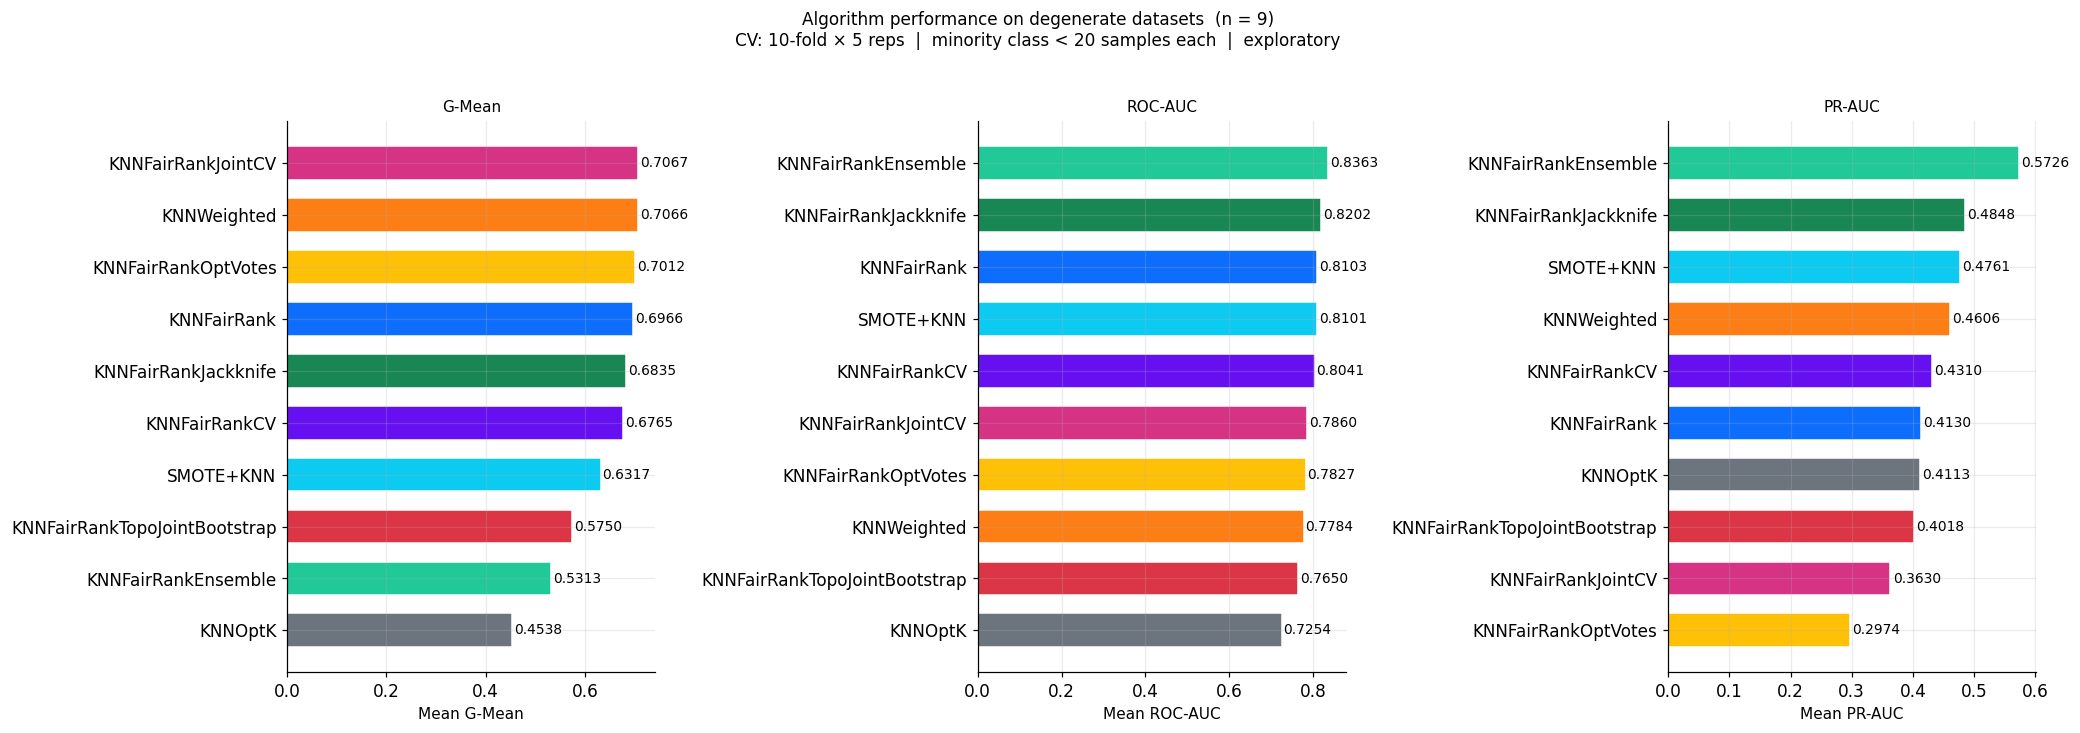

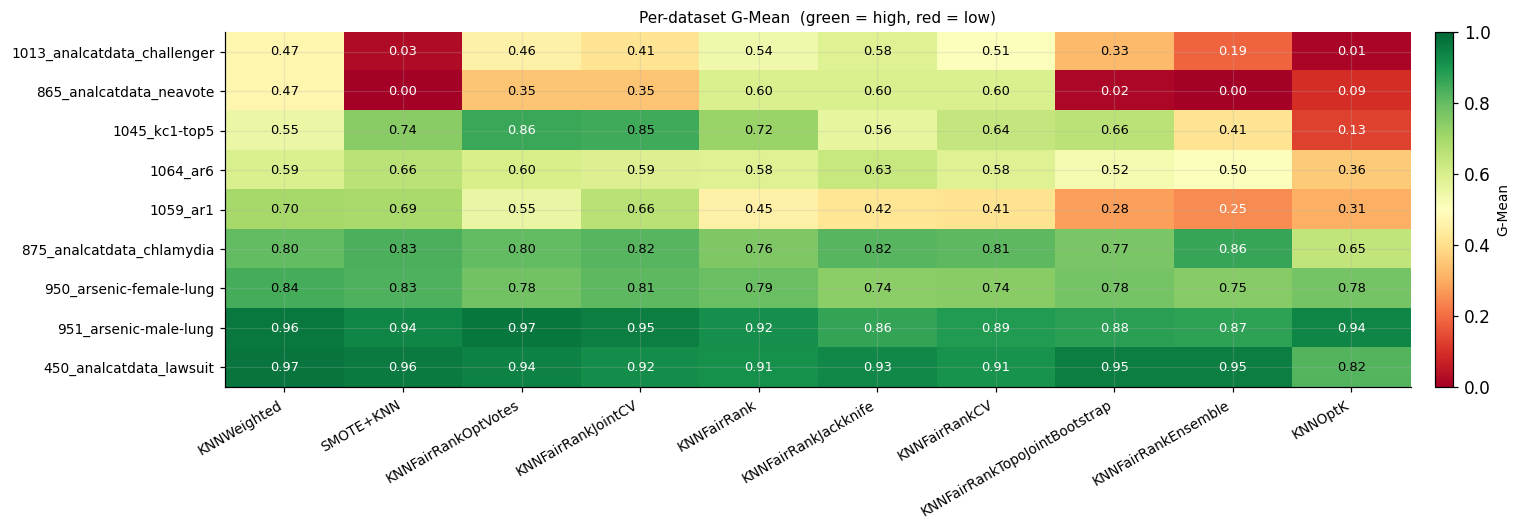

In [20]:
# ── 8. Load degenerate results and compute metrics ──────────────────────────
import os

_degen_candidates = [
    "results/tables/benchmark_5rep_degenerate.csv",
    "results/tables/benchmark_1rep_degenerate.csv",
]
_degen_path = next((p for p in _degen_candidates if os.path.exists(p)), None)
_degen_ok   = False

if _degen_path is None:
    print("No degenerate benchmark file found — Section 8 skipped.")
    print("Run the degenerate benchmark cell in phase2_benchmark.ipynb first.")
else:
    _degen_raw = pd.read_csv(_degen_path)
    _degen_raw = compute_metrics(_degen_raw)
    _degen_raw = _degen_raw[_degen_raw["algorithm"].isin(ALGOS)].copy()

    degen_agg = (
        _degen_raw
        .groupby(["dataset", "algorithm"])[["mcc", "g_mean", "f1", "roc_auc", "pr_auc"]]
        .mean().reset_index()
    )
    _n_ds  = degen_agg["dataset"].nunique()
    _n_alg = degen_agg["algorithm"].nunique()
    _reps  = _degen_raw["repeat"].nunique()
    _folds = _degen_raw["fold"].nunique()
    _degen_ok = True

    print(f"Loaded: {os.path.basename(_degen_path)} — "
          f"{_n_ds} datasets · {_n_alg} algorithms · {_folds}-fold × {_reps} reps")

    # ── Summary table ─────────────────────────────────────────────────────
    degen_summary = (
        degen_agg.groupby("algorithm")[["mcc", "g_mean", "f1", "roc_auc", "pr_auc"]]
        .mean()
        .sort_values("g_mean", ascending=False)
    )
    degen_summary.columns = ["MCC", "G-Mean", "F1", "ROC-AUC", "PR-AUC"]
    print(f"\nMean performance on {_n_ds} degenerate datasets (descriptive only):")
    print(degen_summary.round(4).to_string())

    # ── Average ranks ─────────────────────────────────────────────────────
    _dp = {m: degen_agg.pivot(index="dataset", columns="algorithm", values=m).dropna()
           for m in ["g_mean", "roc_auc", "pr_auc"]}
    degen_ranks = pd.DataFrame({
        "G-Mean":  _dp["g_mean"].rank(axis=1, ascending=False).mean(),
        "ROC-AUC": _dp["roc_auc"].rank(axis=1, ascending=False).mean(),
        "PR-AUC":  _dp["pr_auc"].rank(axis=1, ascending=False).mean(),
    }).sort_values("G-Mean")
    print(f"\nAverage ranks on {_n_ds} degenerate datasets  (1 = best):")
    print(degen_ranks.round(2).to_string())

    # ── Bar charts ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(19, max(4, _n_alg * 0.65)))
    for ax, metric, xlabel in [
        (axes[0], "g_mean",  "Mean G-Mean"),
        (axes[1], "roc_auc", "Mean ROC-AUC"),
        (axes[2], "pr_auc",  "Mean PR-AUC"),
    ]:
        means  = degen_agg.groupby("algorithm")[metric].mean().sort_values()
        colors = [PALETTE.get(a, "#adb5bd") for a in means.index]
        bars   = ax.barh(means.index, means.values, color=colors,
                         edgecolor="white", height=0.65)
        for bar, val in zip(bars, means.values):
            ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
                    f"{val:.4f}", va="center", fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
    axes[0].set_title("G-Mean", fontsize=10)
    axes[1].set_title("ROC-AUC", fontsize=10)
    axes[2].set_title("PR-AUC", fontsize=10)
    plt.suptitle(
        f"Algorithm performance on degenerate datasets  (n = {_n_ds})\n"
        f"CV: {_folds}-fold × {_reps} reps  |  minority class < 20 samples each  |  exploratory",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig("results/figures/degen_performance.png", bbox_inches="tight")
    plt.show()

    # ── Per-dataset G-Mean heatmap ────────────────────────────────────────
    _piv = degen_agg.pivot(index="dataset", columns="algorithm", values="g_mean")
    _piv = _piv[degen_ranks.index]           # order columns by G-Mean rank
    _piv = _piv.sort_values(_piv.columns[0]) # order rows by best-alg score

    fig2, ax2 = plt.subplots(figsize=(14, max(3, _n_ds * 0.55)))
    im = ax2.imshow(_piv.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    for i in range(_piv.shape[0]):
        for j in range(_piv.shape[1]):
            v = _piv.values[i, j]
            ax2.text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=8.5, color="white" if v < 0.25 or v > 0.85 else "black")
    ax2.set_xticks(range(_piv.shape[1]))
    ax2.set_xticklabels(_piv.columns, rotation=30, ha="right", fontsize=9)
    ax2.set_yticks(range(_piv.shape[0]))
    ax2.set_yticklabels([d.replace("dataset_","") for d in _piv.index], fontsize=9)
    fig2.colorbar(im, ax=ax2, fraction=0.02, pad=0.02).set_label("G-Mean", fontsize=9)
    ax2.set_title("Per-dataset G-Mean  (green = high, red = low)", fontsize=10)
    plt.tight_layout()
    plt.savefig("results/figures/degen_gmean_heatmap.png", bbox_inches="tight")
    plt.show()


### 8.1 Results

The degenerate regime produces a substantially different ranking profile from the
40-dataset main benchmark — and not in the direction the theory predicted.

**G-Mean.** KNNWeighted ranks first (avg rank 3.56), followed by SMOTE+KNN (3.89)
and KNNFairRankOptVotes (3.94). Notably, KNNFairRankJointCV — the strongest algorithm
on the main benchmark — drops to fourth (4.28). By raw mean, JointCV and Weighted are
virtually tied (0.707 each), but Weighted is more consistently above average across
individual datasets. The CV-based variants (JointCV, OptVotes, FairRankCV) rely on an
inner cross-validation to select hyperparameters; with only 7–19 minority training samples
per outer fold, that inner CV finds unreliable optima, introducing variance that erodes
their relative ranking.

**ROC-AUC and PR-AUC.** KNNFairRankEnsemble ranks first on both (1.89 and 1.33), with
KNNFairRankJackknife second on both (3.67 and 3.11). This is precisely the same split
seen on the 40 valid datasets. The Ensemble's probability averaging mechanism appears
robust regardless of minority class size — it does not depend on inner CV, only on
aggregating vote fractions across correction strengths, which is defined even with very
few minority samples. KNNFairRankJointCV, by contrast, ranks seventh on ROC-AUC (7.06)
in this regime — the inner CV optimisation that makes it sharp for G-Mean actively
degrades its probability calibration here.

**Extreme cases.** The two most degenerate datasets — analcatdata_neavote (7 minority
samples) and analcatdata_challenger (9 minority, 2 features) — reveal a clear robustness
ordering. The base FairRank variants (KNNFairRank, KNNFairRankCV, KNNFairRankJackknife)
achieve G-Mean ≈ 0.60 on neavote and ≈ 0.50–0.58 on challenger, without any
hyperparameter optimisation. SMOTE+KNN and KNNFairRankEnsemble collapse to 0.00 and
0.19 on challenger and to 0.00 each on neavote. The reason SMOTE fails in these extreme
cases is that interpolating between 7 real points in feature space often produces
synthetic samples outside the true minority region, and some outer-CV test folds receive
zero minority examples — making sensitivity undefined and G-Mean zero.

### 8.2 Interpretation

These results partially contradict the expectation that SMOTE's synthetic oversampling
gives it a structural edge when minority examples are scarce. In practice, the quality
of SMOTE's interpolation depends on having enough real minority samples to form a
meaningful neighbourhood — with 7–9 points that assumption breaks down.

The base FairRank correction does not make this assumption: it adjusts the comparison
rank mathematically from the class counts alone, so it remains well-defined even with
seven training minority examples. This robustness comes at a cost — the base variant
has no free parameters to tune and cannot adapt to dataset geometry — but in the
degenerate regime the absence of a fragile inner optimisation is an advantage, not a
limitation.

KNNWeighted's first-place G-Mean rank is similarly explained: frequency weighting by
`r = N_maj / N_min` is computed from class counts and requires no fitting beyond the
training data itself.

*With n = 9 datasets none of these differences are statistically testable.
The results are exploratory evidence only.*


\
## 9 · Discussion

### 9.1 Main findings

**No single algorithm dominates all metrics — the results split cleanly by metric type.**

**Threshold-based metrics (G-Mean, MCC):** KNNFairRankJointCV ranks #1 (mean G-Mean = 0.796
vs 0.631 for KNNOptK). It is not significantly better than SMOTE+KNN after Holm correction
with 9 comparisons (p_corr = 0.136, Δ = +0.030), but leads the ranking consistently.

**Ranking metrics (ROC-AUC, PR-AUC):** KNNFairRankEnsemble ranks #1 on both
(ROC-AUC = 0.878, PR-AUC = 0.649). It is **statistically significantly better than
SMOTE+KNN** on both (ROC-AUC: p_corr = 0.0000, Δ = +0.034; PR-AUC: p_corr = 0.0000,
Δ = +0.081) — the only algorithm to achieve this. KNNFairRankJackknife is also
significantly better than SMOTE+KNN on ROC-AUC (p_corr = 0.043, Δ = +0.024).

**The trade-off within the FairRank family is interpretable:**
KNNFairRankEnsemble averages vote fractions across multiple correction strengths α,
producing smoother probability scores that excel at ranking but sit near 0.5 for borderline
queries — degrading G-Mean (rank 6.57). KNNFairRankJointCV selects a single optimal
(n_votes, α) pair, producing crisper decisions at the cost of probability resolution.

**MCC and F1 show no significant differences** between algorithms, consistent with the
7-algorithm analysis. These metrics are less discriminative under class imbalance and
should not be used as the primary comparison criterion.

### 9.2 Limitations

- **n_repetitions = 5** × 10-fold CV → **50 evaluation splits per dataset**, providing
  stable rank estimates across the Friedman framework.
- The Poisson-uniform density model assumes class regions are convex and uniformly
  distributed. KNNFairRankCV relaxes this via the calibrated exponent $\alpha$.
- Very high IR datasets (Q4, IR > 37): all algorithms degrade. The fair-rank correction
  factor $r$ grows large, and boundary points become numerically unstable.

### 9.3 Position relative to prior work

KNNFairRank is closest to neighbourhood-adaptive methods but differs fundamentally:
rather than changing the distance metric (DANN), we change the **rank at which we compare
across classes**. The correction is fully interpretable — it follows directly from
order statistics — and avoids the eigendecomposition cost of DANN.

Compared to SMOTE, KNNFairRank operates entirely at prediction time: no synthetic samples,
no stored oversampled dataset, no risk of minority cluster overfitting.


## 10 · Conclusions

We have demonstrated that standard KNN suffers a **structural, dimension-independent
bias** under class imbalance, and derived a principled correction from order statistics.

The core result — $k_{eff} = r = N_{maj}/N_{min}$ — is mathematically exact under the
Poisson-uniform assumption and dimension-free by construction. The extended family reveals
a **metric-dependent specialisation**: joint optimisation of $(n_{votes}, \alpha)$ in
**KNNFairRankJointCV** produces the best threshold-based decisions (G-Mean, MCC), while
ensemble averaging over correction strengths in **KNNFairRankEnsemble** produces the best
probability rankings (ROC-AUC, PR-AUC), significantly outperforming SMOTE+KNN on both.
The choice between them depends on the deployment context: binary decisions favour
JointCV; scoring and ranking applications favour Ensemble.

### Key results summary

| Finding | Evidence |
|:---|:---|
| Friedman significant for all 5 metrics | p ≤ 1.4×10⁻¹² |
| All FairRank variants sig. better than KNNOptK in G-Mean | Wilcoxon p_corr ≈ 0 |
| KNNFairRankEnsemble sig. better than SMOTE in ROC-AUC | p_corr = 0.0000, Δ = +0.034 |
| KNNFairRankEnsemble sig. better than SMOTE in PR-AUC | p_corr = 0.0000, Δ = +0.081 |
| KNNFairRankJackknife sig. better than SMOTE in ROC-AUC | p_corr = 0.043, Δ = +0.024 |
| MCC and F1: no sig. differences (less discriminative under imbalance) | — |
| Nemenyi: no metric fully separated at #1 (CD = 1.935, k=10) | — |

---

## References

- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *JMLR*, 7, 1–30.  
- Hastie, T. & Tibshirani, R. (1996). Discriminant adaptive nearest-neighbor classification. *IEEE TPAMI*, 18(6), 607–616.  
- Chawla, N.V. et al. (2002). SMOTE: Synthetic minority over-sampling technique. *JAIR*, 16, 321–357.  
- Rushter/MLAlgorithms (GitHub) — core KNN loop adapted with sklearn-compatible interface.
